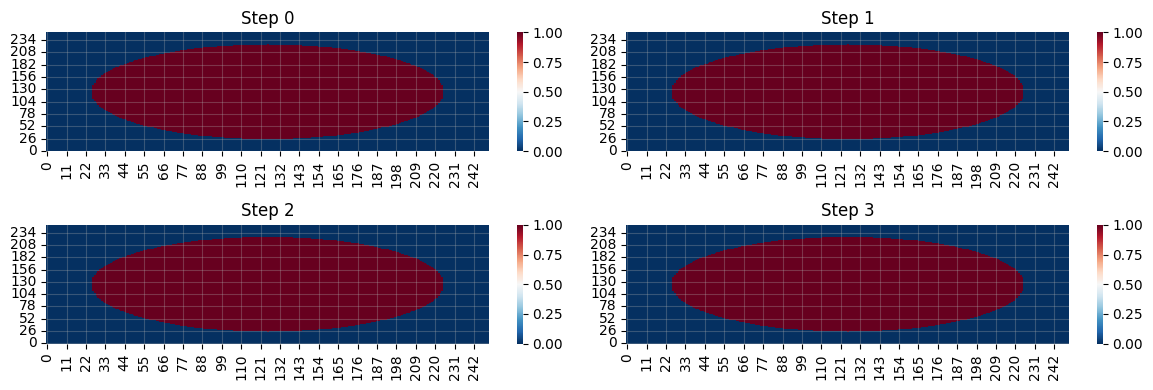

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
c = 1 / np.sqrt(eps * mu)

# --- domínio ---
a = 0.5 # raio da cavidade
Nx = Ny = 250
dx = dy = 5e-3
cx, cy = Nx // 2, Ny // 2
L = Nx * dx # dimensao do grid

dt = 10e-12
Nt = 1000
T = Nt * dt

# define os grids - desenha a célula para o caso 2D TM
grid_x_Ez = np.linspace(0, L, Nx + 1)
grid_y_Ez = np.linspace(0, L, Ny + 1)
grid_t_Ez = np.linspace(0, T, Nt + 1)

grid_x_Hx = np.linspace(0, L, Nx + 1)
grid_y_Hx = np.linspace(dy/2, L - dy/2, Ny)
grid_t_Hx = np.linspace(dt/2, T - dt/2, Nt)

grid_x_Hy = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Hy = np.linspace(0, L, Ny + 1)
grid_t_Hy = np.linspace(dt/2, T - dt/2, Nt)

# mascara para a cavidade
X, Y = np.meshgrid(grid_x_Ez, grid_y_Ez, indexing='ij')
mask = (X - cx * dx)**2 + (Y - cy * dy)**2 <= a**2

# ponta de prova para coletar pontos para a FFT no centro da cavidade
probe = []

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(20, Nt - 5, 6, dtype=int)
Ez_snapshots = []

Ez_curr = Ez_next = np.zeros((grid_x_Ez.shape[0], grid_y_Ez.shape[0]))
Hx_curr = Hx_next = np.zeros((grid_x_Hx.shape[0], grid_y_Hx.shape[0]))
Hy_curr = Hy_next = np.zeros((grid_x_Hy.shape[0], grid_y_Hy.shape[0]))

fig, axes = plt.subplots(2, 2, figsize=(12, 4))

for i, ax in enumerate(axes.flatten()):
    sns.heatmap(mask, annot=False, cmap='RdBu_r', ax=ax)
    ax.set_title(f"Step {i}")
    ax.invert_yaxis()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
for n in range(Nt-1):
    # --- fonte (pulso gaussiano no tempo) ---
    t0 = 50
    spread = 15
    source_gaussiano = np.exp(-((n - t0)**2) / spread**2)

    # --- fonte (senoidal no tempo) ---
    frequency = 1e9  # 1 GHz
    source_senoidal = np.sin(2 * np.pi * frequency * n * dt)

    Ez_curr[cx, cy] += source_senoidal

    Hx_next[:, :] = Hx_curr[:, :] - (dt/(mu*dy)) * (
        Ez_curr[:, 1:] - Ez_curr[:, :-1]
    )

    Hy_next[:, :] = Hy_curr[:, :] + (dt/(mu*dx)) * (
        Ez_curr[1:, :] - Ez_curr[:-1, :]
    )

    Ez_next[1:-1, 1:-1] = Ez_curr[1:-1, 1:-1] + (dt/eps) * (
        (Hy_next[1:, 1:-1] - Hy_next[:-1, 1:-1]) / dx -
        (Hx_next[1:-1, 1:] - Hx_next[1:-1, :-1]) / dy
    )

    # zero nas extremidades e para fora da cavidade (condição de contorno)
    Ez_next[~mask] = 0

    # salva o valor no centro para a FFT
    probe.append(Ez_next[cx + 25, cy + 25])

    # atualiza os campos para o próximo passo
    Ez_curr = Ez_next.copy()
    Hx_curr = Hx_next.copy()
    Hy_curr = Hy_next.copy()

    # salva para os snapshots
    if n in n_snapshots:
        Ez_snapshots.append(Ez_curr.copy())



ValueError: operands could not be broadcast together with shapes (249,251) (251,249) 

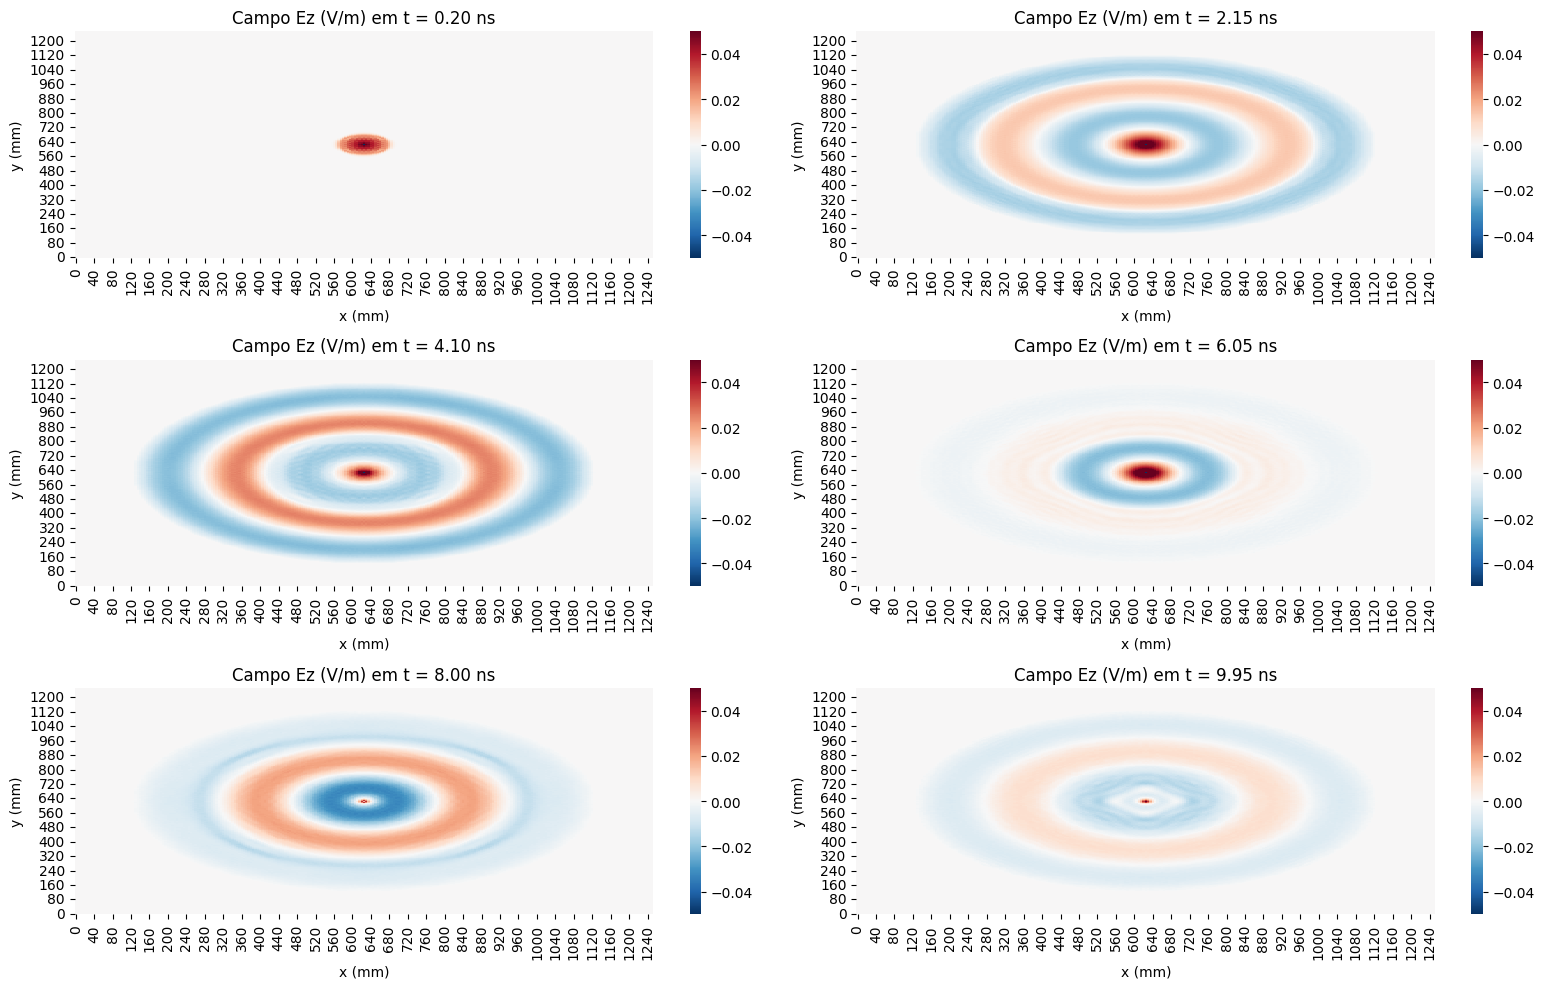

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    sns.heatmap(Ez_snapshots[i], ax=ax, annot=False, cmap='RdBu_r',vmin=-0.05, vmax=0.05,center=0)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Campo Ez (V/m) em t = {n_snapshots[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1000:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1000:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
Ez_snapshots[0]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(251, 251))

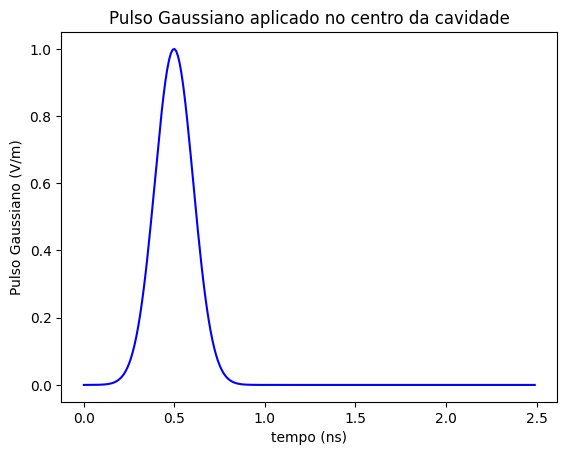

In [ ]:
t0 = 50
spread = 15
source_gaussiano = np.exp(-((np.linspace(0,Nt//4, Nt//4) - t0)**2) / spread**2)
tgrid = np.arange(Nt//4) * dt * 1e9  # Convert to nanoseconds

# 2. Create a figure and axis
fig, ax = plt.subplots()

# 3. Plot the data
ax.plot(tgrid,source_gaussiano, label='Pulso Gaussiano (V/m)', color='blue')

# 4. Customize the plot
ax.set_title('Pulso Gaussiano aplicado no centro da cavidade')
ax.set_xlabel('tempo (ns)')
ax.set_ylabel('Pulso Gaussiano (V/m)')

# 5. Display the result
plt.show()

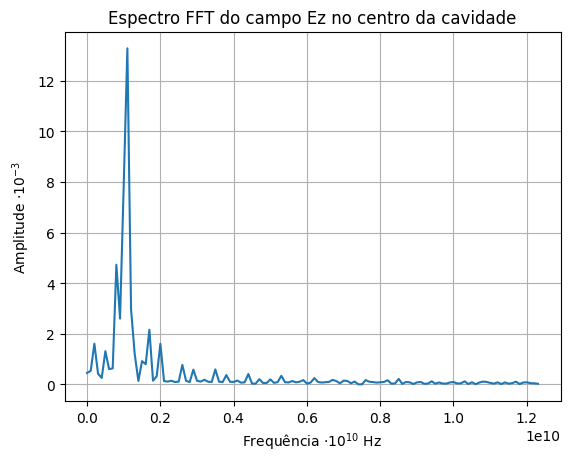

In [ ]:
# 2. Compute the FFT
yf = fft(probe)
xf = fftfreq(len(probe), dt)

# 3. Plot the results (Positive frequencies only)
plt.plot(xf[:len(probe)//8], 1e3 * 2.0/len(probe) * np.abs(yf[:len(probe)//8]))
plt.title("Espectro FFT do campo Ez no centro da cavidade")
plt.xlabel(r"Frequência $\cdot 10^{10}$ Hz")
plt.ylabel(r"Amplitude $\cdot 10^{-3}$")
plt.grid()
plt.show()

In [ ]:
print(dt)

print(1 / (c * np.sqrt( (1/dx)**2 + 1/dy**2) ))

1e-11
1.1793271683335256e-11
